In [16]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style for plots (for later use)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
import pandas as pd
import numpy as np
import glob
import os

#  PART 1: LOAD AND MERGE DATA 

# 1. Setup File Path
data_folder = 'data'
file_pattern = os.path.join(data_folder, "*.csv")
all_files = glob.glob(file_pattern)

print(f"Found {len(all_files)} CSV files in '{data_folder}' folder.")


# We use a list to store dataframes first
df_list = []

for filename in all_files:
    print(f"Reading: {filename}...")
    try:
        # NREL NSRDB files have 2 rows of metadata. We skip them to get to the headers.
        # If your file does NOT have metadata, remove 'skiprows=2'
        current_df = pd.read_csv(filename, skiprows=2)
        df_list.append(current_df)
    except Exception as e:
        print(f"Error reading {filename}: {e}")

# Merge all into one main DataFrame
if df_list:
    df = pd.concat(df_list, ignore_index=True)
    print("\nSUCCESS: All files merged.")
else:
    print("\nERROR: No data loaded. Check your folder path.")


Found 0 CSV files in 'data' folder.

ERROR: No data loaded. Check your folder path.


In [ ]:

#  PART 2: TIME INDEX CREATION (CRITICAL) 

# We need to combine Year, Month, Day, Hour, Minute into a single 'Datetime' object
# This is required for any Time Series analysis
print("Creating Datetime Index...")
time_cols = ['Year', 'Month', 'Day', 'Hour', 'Minute']

# Check if these columns exist first
if all(col in df.columns for col in time_cols):
    df['Datetime'] = pd.to_datetime(df[time_cols])
    df.set_index('Datetime', inplace=True)
    df.sort_index(inplace=True) # Ensure time is in order after merging
    
    # Drop the original time columns to clean up
    df.drop(columns=time_cols, inplace=True)
    print("Datetime index created and sorted.")
else:
    print("WARNING: Could not find standard time columns. Skipping index creation.")


Creating Datetime Index...
Datetime index created and sorted.


In [ ]:
# STEP 1:  DATA OVERVIEW + COMBINE YEARLY NSRDB CSVs

import os
import re
from pathlib import Path
import pandas as pd


RAW_DIR = Path("data/raw")  
OUTPUT_DIR = Path("data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


FAST_PREVIEW = False   
PREVIEW_ROWS = 20000   


print("=== ENVIRONMENT DEBUG ===")
print("Current working directory (cwd):", Path.cwd())
print("RAW_DIR resolved path:", RAW_DIR.resolve())
print("RAW_DIR exists?:", RAW_DIR.exists())
print()

if RAW_DIR.exists():
    print("Contents of RAW_DIR:")
    items = sorted(RAW_DIR.iterdir())
    if not items:
        print(" - (empty folder)")
    else:
        for p in items:
            print(" -", p.name)
print("\n")


# 2) FIND CSV FILES

patterns = [
    "*.csv",
    "*.CSV"
]

all_csvs = []
for pat in patterns:
    all_csvs.extend(sorted(RAW_DIR.glob(pat)))

# Remove duplicates (in case patterns overlap)
csv_files = sorted(set(all_csvs))

print("=== FILE SEARCH ===")
print(f"Found {len(csv_files)} CSV files total in {RAW_DIR}:")
for f in csv_files:
    print(" -", f.name)
print()

if len(csv_files) == 0:
    print(" No CSV files found.")
    print("Common fixes:")
    print("1) Confirm your notebook is running from the project root (where 'data/raw' exists).")
    print("2) If you're using Colab, upload files or mount Drive, then update RAW_DIR.")
    print("3) If your folder is named differently, update RAW_DIR at the top.")
    raise SystemExit("Stop: No CSV files to process.")


# 3) DETECT YEAR FROM FILENAME (2018-2024)

year_pattern = re.compile(r"(2018|2019|2020|2021|2022|2023|2024)")

files_by_year = {}
unknown_year_files = []

for f in csv_files:
    m = year_pattern.search(f.name)
    if m:
        year = int(m.group(1))
        files_by_year.setdefault(year, []).append(f)
    else:
        unknown_year_files.append(f)

print("=== YEAR DETECTION ===")
for y in sorted(files_by_year.keys()):
    print(f"{y}: {len(files_by_year[y])} file(s)")
    for ff in files_by_year[y]:
        print("   -", ff.name)

if unknown_year_files:
    print("\n Files with NO year detected in filename:")
    for ff in unknown_year_files:
        print(" -", ff.name)

print()

expected_years = list(range(2018, 2025))
missing = [y for y in expected_years if y not in files_by_year]
if missing:
    print(" Missing expected years (based on filename):", missing)
    print("If your files don't include the year in the filename, rename them or tell me the naming format.\n")

=== ENVIRONMENT DEBUG ===
Current working directory (cwd): c:\Users\Nikhil\Desktop\data mining nikhil
RAW_DIR resolved path: C:\Users\Nikhil\Desktop\data mining nikhil\data\raw
RAW_DIR exists?: True

Contents of RAW_DIR:
 - 1454957_43.00_-110.39_2018.csv
 - 1454957_43.00_-110.39_2019.csv
 - 1454957_43.00_-110.39_2020.csv
 - 1454957_43.00_-110.39_2021.csv
 - 1454957_43.00_-110.39_2022.csv
 - 1454957_43.00_-110.39_2023.csv
 - 1454957_43.00_-110.39_2024.csv


=== FILE SEARCH ===
Found 7 CSV files total in data\raw:
 - 1454957_43.00_-110.39_2018.csv
 - 1454957_43.00_-110.39_2019.csv
 - 1454957_43.00_-110.39_2020.csv
 - 1454957_43.00_-110.39_2021.csv
 - 1454957_43.00_-110.39_2022.csv
 - 1454957_43.00_-110.39_2023.csv
 - 1454957_43.00_-110.39_2024.csv

=== YEAR DETECTION ===
2018: 1 file(s)
   - 1454957_43.00_-110.39_2018.csv
2019: 1 file(s)
   - 1454957_43.00_-110.39_2019.csv
2020: 1 file(s)
   - 1454957_43.00_-110.39_2020.csv
2021: 1 file(s)
   - 1454957_43.00_-110.39_2021.csv
2022: 1 file

In [ ]:

# STEP 1: NSRDB CSV with 2 header lines
#   - Row 1: metadata header
#   - Row 2: metadata values
#   - Row 3: real data header
#   - Row 4: data


import re
from pathlib import Path
import pandas as pd

RAW_DIR = Path("data/raw")
OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

csv_files = sorted(RAW_DIR.glob("*.csv"))
print(f"Found {len(csv_files)} files in {RAW_DIR.resolve()}:")
for f in csv_files:
    print(" -", f.name)

if not csv_files:
    raise SystemExit("No CSVs found. Check RAW_DIR.")

year_pattern = re.compile(r"(2018|2019|2020|2021|2022|2023|2024)")


# 1) Read each file properly

all_data = []
all_meta = []

print("\n=== READING FILES (metadata + data) ===")
for f in csv_files:
    m = year_pattern.search(f.name)
    year_in_name = int(m.group(1)) if m else None

    # Metadata: header row + 1 data row
    meta = pd.read_csv(f, nrows=1)          # reads the header names
    meta_vals = pd.read_csv(f, nrows=1, header=0, skiprows=1)  # reads row2 as values with row1 header
    # combine into one-row dataframe
    meta_row = meta_vals.copy()
    meta_row["source_file"] = f.name
    meta_row["year_in_filename"] = year_in_name
    all_meta.append(meta_row)

    # Actual time-series data: start from row3 header (skip first 2 rows)
    df = pd.read_csv(f, skiprows=2)   # now header becomes "Year,Month,Day,..."
    df["source_file"] = f.name
    df["year_in_filename"] = year_in_name
    all_data.append(df)

    print(f" {f.name}: data shape={df.shape}, meta columns={meta_row.shape[1]}")

meta_df = pd.concat(all_meta, ignore_index=True)
df = pd.concat(all_data, ignore_index=True)

print("\n=== COMBINED RESULTS ===")
print("Meta combined shape:", meta_df.shape)
print("Data combined shape:", df.shape)
print("Data columns count:", df.shape[1])
print("\nData columns:")
print(list(df.columns))


# 2) Quick metadata check (location, lat/lon, units)

print("\n=== METADATA QUICK CHECK (first row) ===")
print(meta_df.head(1).T)


# 3) Build timestamp properly

required_time_cols = {"Year", "Month", "Day", "Hour", "Minute"}
print("\n=== TIMESTAMP BUILD ===")

if required_time_cols.issubset(df.columns):
    df["timestamp"] = pd.to_datetime(
        df[["Year", "Month", "Day", "Hour", "Minute"]],
        errors="coerce"
    )
    bad_ts = df["timestamp"].isna().sum()
    print("timestamp created  | Bad timestamps:", bad_ts)

    df = df.sort_values("timestamp").reset_index(drop=True)
    print("Time range:", df["timestamp"].min(), "to", df["timestamp"].max())
else:
    print(" Missing time columns. Found:", [c for c in df.columns if c.lower() in ["year","month","day","hour","minute"]])
    raise SystemExit("Stop: time columns not found as expected.")

Found 7 files in C:\Users\Nikhil\Desktop\data mining nikhil\data\raw:
 - 1454957_43.00_-110.39_2018.csv
 - 1454957_43.00_-110.39_2019.csv
 - 1454957_43.00_-110.39_2020.csv
 - 1454957_43.00_-110.39_2021.csv
 - 1454957_43.00_-110.39_2022.csv
 - 1454957_43.00_-110.39_2023.csv
 - 1454957_43.00_-110.39_2024.csv

=== READING FILES (metadata + data) ===
 1454957_43.00_-110.39_2018.csv: data shape=(17520, 30), meta columns=48
 1454957_43.00_-110.39_2019.csv: data shape=(17520, 30), meta columns=48
 1454957_43.00_-110.39_2020.csv: data shape=(17520, 30), meta columns=48
 1454957_43.00_-110.39_2021.csv: data shape=(17520, 30), meta columns=48
 1454957_43.00_-110.39_2022.csv: data shape=(17520, 30), meta columns=48
 1454957_43.00_-110.39_2023.csv: data shape=(17520, 30), meta columns=48
 1454957_43.00_-110.39_2024.csv: data shape=(17520, 30), meta columns=48

=== COMBINED RESULTS ===
Meta combined shape: (7, 50)
Data combined shape: (122640, 30)
Data columns count: 30

Data columns:
['Year', 'Mon

In [ ]:

# 
# 4) Convert key columns to numeric 
# 
print("\n=== TYPE CLEANUP (numeric coercion) ===")

# choose a reasonable set of columns 
candidate_numeric = [
    "Temperature", "Dew Point", "Relative Humidity", "Pressure",
    "Wind Speed", "Wind Direction", "Precipitable Water",
    "GHI", "DHI", "DNI", "Clearsky GHI", "Clearsky DHI", "Clearsky DNI",
    "Solar Zenith Angle", "Cloud Type", "Fill Flag",
    "Alpha", "Aerosol Optical Depth", "Asymmetry", "Ozone", "SSA", "Surface Albedo",
]
numeric_cols = [c for c in candidate_numeric if c in df.columns]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Numeric columns coerced:", numeric_cols)

# 
# 5) Data Quality Overview
# 
print("\n=== DATA QUALITY OVERVIEW ===")
print("Rows:", len(df), " | Columns:", df.shape[1])

# Missingness top 15
missing_rate = df.isna().mean().sort_values(ascending=False)
print("\nTop missing columns (rate):")
print(missing_rate.head(15))

# Duplicates on timestamp (should  be 0)
dup_ts = df["timestamp"].duplicated().sum()
print("\nDuplicate timestamps:", dup_ts)

# Confirm expected irradiance columns
irr_cols = [c for c in ["GHI","DNI","DHI","Clearsky GHI","Clearsky DNI","Clearsky DHI"] if c in df.columns]
print("\nIrradiance columns detected:", irr_cols)
if irr_cols:
    print(df[irr_cols].describe().T)



=== TYPE CLEANUP (numeric coercion) ===
Numeric columns coerced: ['Temperature', 'Dew Point', 'Relative Humidity', 'Pressure', 'Wind Speed', 'Wind Direction', 'Precipitable Water', 'GHI', 'DHI', 'DNI', 'Clearsky GHI', 'Clearsky DHI', 'Clearsky DNI', 'Solar Zenith Angle', 'Cloud Type', 'Fill Flag', 'Alpha', 'Aerosol Optical Depth', 'Asymmetry', 'Ozone', 'SSA', 'Surface Albedo']

=== DATA QUALITY OVERVIEW ===
Rows: 122640  | Columns: 31

Top missing columns (rate):
Year                     0.0
Month                    0.0
Day                      0.0
Hour                     0.0
Minute                   0.0
Temperature              0.0
Alpha                    0.0
Aerosol Optical Depth    0.0
Asymmetry                0.0
Clearsky DHI             0.0
Clearsky DNI             0.0
Clearsky GHI             0.0
Cloud Fill Flag          0.0
Cloud Type               0.0
Dew Point                0.0
dtype: float64

Duplicate timestamps: 0

Irradiance columns detected: ['GHI', 'DNI', 'DHI', 'Cle

In [ ]:


# 6) Save combined clean output

out_data = OUT_DIR / "nsrdb_2018_2024_combined_clean.csv"
out_meta = OUT_DIR / "nsrdb_metadata_2018_2024.csv"

df.to_csv(out_data, index=False)
meta_df.to_csv(out_meta, index=False)

print("\n Saved:")
print(" - Data:", out_data.resolve())
print(" - Metadata:", out_meta.resolve())


# 7) Show final sanity samples

print("\n=== FINAL SAMPLES ===")
print("\nFirst 3 rows (timestamp + key vars if present):")
show_cols = ["timestamp"] + [c for c in ["GHI","DNI","DHI","Temperature","Relative Humidity","Pressure","Wind Speed","Cloud Type"] if c in df.columns]
print(df[show_cols].head(3))

print("\nLast 3 rows:")
print(df[show_cols].tail(3))



 Saved:
 - Data: C:\Users\Nikhil\Desktop\data mining nikhil\data\processed\nsrdb_2018_2024_combined_clean.csv
 - Metadata: C:\Users\Nikhil\Desktop\data mining nikhil\data\processed\nsrdb_metadata_2018_2024.csv

=== FINAL SAMPLES ===

First 3 rows (timestamp + key vars if present):
            timestamp  GHI  DNI  DHI  Temperature  Relative Humidity  \
0 2018-01-01 00:00:00    0    0    0        -15.1              93.38   
1 2018-01-01 00:30:00    0    0    0        -15.8              98.95   
2 2018-01-01 01:00:00    0    0    0        -16.5              93.72   

   Pressure  Wind Speed  Cloud Type  
0       758         1.1           0  
1       758         1.1           0  
2       758         1.1           0  

Last 3 rows:
                 timestamp  GHI  DNI  DHI  Temperature  Relative Humidity  \
122637 2024-12-31 22:30:00  203  833   36        -11.5              98.68   
122638 2024-12-31 23:00:00  125  729   28        -12.7              89.29   
122639 2024-12-31 23:30:00   50

Data Preparation (deep cleaning + engineered features + modelling

In [ ]:
# STEP 2:  DATA PREPARATION 
# - Cleans + validates time series
# - Creates daylight features, clearness index, Solar_Class
# - Builds separate modelling tables for clustering/classification/forecasting
# - Exports processed datasets and a preparation summary

import numpy as np
import pandas as pd
from pathlib import Path

# Load combined clean data

DATA_PATH = Path("data/processed/nsrdb_2018_2024_combined_clean.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

print("Loaded:", DATA_PATH.resolve())
print("Initial shape:", df.shape)
print("Initial time range:", df["timestamp"].min(), "to", df["timestamp"].max())


# Sort + uniqueness

df = df.sort_values("timestamp").reset_index(drop=True)

dup_ts = df["timestamp"].duplicated().sum()
print("\nDuplicate timestamps:", dup_ts)

if dup_ts > 0:
    # keep first occurrence (conservative)
    df = df.drop_duplicates(subset=["timestamp"], keep="first").reset_index(drop=True)
    print("After dropping duplicate timestamps:", df.shape)


# 2) Check expected sampling frequency 

deltas = df["timestamp"].diff().dropna().dt.total_seconds()
mode_delta = deltas.mode().iloc[0] if len(deltas.mode()) else None
print("\nMost common time step (seconds):", mode_delta)

#  1800 seconds (30 minutes) in  dataset
if mode_delta is not None:
    print("Most common time step (minutes):", mode_delta / 60)

# Count irregular gaps
irregular = (deltas != mode_delta).sum() if mode_delta is not None else np.nan
print("Irregular step count:", irregular)



Loaded: C:\Users\Nikhil\Desktop\data mining nikhil\data\processed\nsrdb_2018_2024_combined_clean.csv
Initial shape: (122640, 31)
Initial time range: 2018-01-01 00:00:00 to 2024-12-31 23:30:00

Duplicate timestamps: 0

Most common time step (seconds): 1800.0
Most common time step (minutes): 30.0
Irregular step count: 2


In [ ]:

# 3)  key numeric columns 

numeric_cols = [
    "Temperature","Dew Point","Relative Humidity","Pressure",
    "Wind Speed","Wind Direction","Precipitable Water",
    "GHI","DHI","DNI","Clearsky GHI","Clearsky DHI","Clearsky DNI",
    "Solar Zenith Angle","Cloud Type","Fill Flag",
    "Alpha","Aerosol Optical Depth","Asymmetry","Ozone","SSA","Surface Albedo"
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")


# 4) Physical sanity checks 

def sanity_range(name, series, lo=None, hi=None):
    s = series.dropna()
    if s.empty:
        return (name, "empty")
    out_lo = (s < lo).sum() if lo is not None else 0
    out_hi = (s > hi).sum() if hi is not None else 0
    return (name, int(out_lo), int(out_hi), float(s.min()), float(s.max()))

sanity = []
if "GHI" in df: sanity.append(sanity_range("GHI", df["GHI"], lo=0))
if "DNI" in df: sanity.append(sanity_range("DNI", df["DNI"], lo=0))
if "DHI" in df: sanity.append(sanity_range("DHI", df["DHI"], lo=0))
if "Relative Humidity" in df: sanity.append(sanity_range("Relative Humidity", df["Relative Humidity"], lo=0, hi=100))
if "Solar Zenith Angle" in df: sanity.append(sanity_range("Solar Zenith Angle", df["Solar Zenith Angle"], lo=0, hi=180))
if "Wind Speed" in df: sanity.append(sanity_range("Wind Speed", df["Wind Speed"], lo=0))

print("\n=== SANITY CHECKS (out-of-range counts) ===")
for row in sanity:
    print(row)


# 5) Daylight feature engineering

# Daylight: zenith < 90 (sun above horizon). Twilight can be treated later.
df["is_daylight"] = (df["Solar Zenith Angle"] < 90).astype(int)

# Solar elevation (useful for interpretability; elevation = 90 - zenith)
df["solar_elevation"] = 90 - df["Solar Zenith Angle"]

print("\nDaylight ratio:", df["is_daylight"].mean())
print("Solar elevation summary:")
print(df["solar_elevation"].describe())


# 6) Clearness index 

eps = 1e-6
df["clearness_index"] = df["GHI"] / (df["Clearsky GHI"] + eps)
df["clearness_index"] = df["clearness_index"].clip(0, 1.5)

# "cloud_loss" = clearsky - actual (>=0 ideally)
df["cloud_loss"] = (df["Clearsky GHI"] - df["GHI"]).clip(lower=0)

print("\nClearness index summary:")
print(df["clearness_index"].describe())





=== SANITY CHECKS (out-of-range counts) ===
('GHI', 0, 0, 0.0, 1061.0)
('DNI', 0, 0, 0.0, 1114.0)
('DHI', 0, 0, 0.0, 748.0)
('Relative Humidity', 0, 0, 6.71, 100.0)
('Solar Zenith Angle', 0, 0, 19.61, 160.33)
('Wind Speed', 0, 0, 0.0, 2.8000000000000003)

Daylight ratio: 0.506107305936073
Solar elevation summary:
count    122640.000000
mean          0.332872
std          34.615227
min         -70.330000
25%         -26.130000
50%           0.640000
75%          26.850000
max          70.390000
Name: solar_elevation, dtype: float64

Clearness index summary:
count    122640.000000
mean          0.395240
std           0.442580
min           0.000000
25%           0.000000
50%           0.000000
75%           0.977637
max           1.000000
Name: clearness_index, dtype: float64


In [ ]:

# 7) Classification target: Solar_Class (your thresholds)

bins = [-np.inf, 200, 600, np.inf]
labels = [0, 1, 2]
df["Solar_Class"] = pd.cut(df["GHI"], bins=bins, labels=labels).astype(int)

print("\nSolar_Class distribution (counts):")
print(df["Solar_Class"].value_counts().sort_index())
print("\nSolar_Class distribution (%):")
print((df["Solar_Class"].value_counts(normalize=True).sort_index() * 100).round(2))

# Optional: A daylight-only class distribution (useful to discuss imbalance)
day_dist = df[df["is_daylight"]==1]["Solar_Class"].value_counts(normalize=True).sort_index()
print("\nSolar_Class distribution within daylight only (%):")
print((day_dist*100).round(2))


# 8) Feature sets for each model

# Model 1: Clustering (meteorology only; NO irradiance in clustering step)
cluster_features = [
    "Temperature","Relative Humidity","Pressure","Wind Speed",
    "Wind Direction","Precipitable Water","Dew Point",
    "Aerosol Optical Depth","SSA","Ozone"
]
cluster_features = [c for c in cluster_features if c in df.columns]

# Use daylight only (prevents night dominating clusters)
df_cluster = df[df["is_daylight"]==1].copy()
df_cluster = df_cluster.dropna(subset=cluster_features + ["GHI"])

print("\n=== CLUSTER READY ===")
print("Features:", cluster_features)
print("Shape:", df_cluster.shape)

# Model 2: Classification (cheap sensors; exclude irradiance inputs)
class_features = [
    "Temperature","Relative Humidity","Pressure","Wind Speed",
    "Wind Direction","Precipitable Water","Dew Point",
    "Aerosol Optical Depth","SSA","Ozone",
    "Solar Zenith Angle","Cloud Type"
]
class_features = [c for c in class_features if c in df.columns]

df_class = df.dropna(subset=class_features + ["Solar_Class"]).copy()

print("\n=== CLASS READY ===")
print("Features:", class_features)
print("Shape:", df_class.shape)

# Model 3: Forecasting (multivariate)
forecast_features = [
    "GHI","Clearsky GHI","Temperature","Relative Humidity","Pressure",
    "Wind Speed","Precipitable Water","Cloud Type","Solar Zenith Angle"
]
forecast_features = [c for c in forecast_features if c in df.columns]

df_forecast = df.dropna(subset=forecast_features).copy()
print("\n=== FORECAST BASE READY ===")
print("Features:", forecast_features)
print("Shape:", df_forecast.shape)




Solar_Class distribution (counts):
Solar_Class
0    80862
1    25132
2    16646
Name: count, dtype: int64

Solar_Class distribution (%):
Solar_Class
0    65.93
1    20.49
2    13.57
Name: proportion, dtype: float64

Solar_Class distribution within daylight only (%):
Solar_Class
0    32.69
1    40.49
2    26.82
Name: proportion, dtype: float64

=== CLUSTER READY ===
Features: ['Temperature', 'Relative Humidity', 'Pressure', 'Wind Speed', 'Wind Direction', 'Precipitable Water', 'Dew Point', 'Aerosol Optical Depth', 'SSA', 'Ozone']
Shape: (62069, 36)

=== CLASS READY ===
Features: ['Temperature', 'Relative Humidity', 'Pressure', 'Wind Speed', 'Wind Direction', 'Precipitable Water', 'Dew Point', 'Aerosol Optical Depth', 'SSA', 'Ozone', 'Solar Zenith Angle', 'Cloud Type']
Shape: (122640, 36)

=== FORECAST BASE READY ===
Features: ['GHI', 'Clearsky GHI', 'Temperature', 'Relative Humidity', 'Pressure', 'Wind Speed', 'Precipitable Water', 'Cloud Type', 'Solar Zenith Angle']
Shape: (122640, 36

In [ ]:

# 9) Save processed datasets

OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(OUT_DIR / "nsrdb_master_features.csv", index=False)
df_cluster.to_csv(OUT_DIR / "nsrdb_cluster_ready_daylight.csv", index=False)
df_class.to_csv(OUT_DIR / "nsrdb_class_ready.csv", index=False)
df_forecast.to_csv(OUT_DIR / "nsrdb_forecast_base.csv", index=False)

print("\n Saved:")
print(" - nsrdb_master_features.csv")
print(" - nsrdb_cluster_ready_daylight.csv")
print(" - nsrdb_class_ready.csv")
print(" - nsrdb_forecast_base.csv")


# 10) Preparation summary 

print("\n=== PREP SUMMARY (for report) ===")
print(f"Time coverage: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Sampling: most common step = {mode_delta/60:.1f} minutes")
print(f"Rows (all): {len(df)} | Rows (daylight): {int(df['is_daylight'].sum())}")
print("Solar_Class %:", (df["Solar_Class"].value_counts(normalize=True).sort_index()*100).round(2).to_dict())
print("Clustering features:", cluster_features)
print("Classification features:", class_features)
print("Forecast base features:", forecast_features)


 Saved:
 - nsrdb_master_features.csv
 - nsrdb_cluster_ready_daylight.csv
 - nsrdb_class_ready.csv
 - nsrdb_forecast_base.csv

=== PREP SUMMARY (for report) ===
Time coverage: 2018-01-01 00:00:00 to 2024-12-31 23:30:00
Sampling: most common step = 30.0 minutes
Rows (all): 122640 | Rows (daylight): 62069
Solar_Class %: {0: 65.93, 1: 20.49, 2: 13.57}
Clustering features: ['Temperature', 'Relative Humidity', 'Pressure', 'Wind Speed', 'Wind Direction', 'Precipitable Water', 'Dew Point', 'Aerosol Optical Depth', 'SSA', 'Ozone']
Classification features: ['Temperature', 'Relative Humidity', 'Pressure', 'Wind Speed', 'Wind Direction', 'Precipitable Water', 'Dew Point', 'Aerosol Optical Depth', 'SSA', 'Ozone', 'Solar Zenith Angle', 'Cloud Type']
Forecast base features: ['GHI', 'Clearsky GHI', 'Temperature', 'Relative Humidity', 'Pressure', 'Wind Speed', 'Precipitable Water', 'Cloud Type', 'Solar Zenith Angle']


Loaded for EDA: C:\Users\Nikhil\Desktop\data mining nikhil\data\processed\nsrdb_master_features.csv
Shape: (122640, 36)

Daylight rows: 62069  ( 50.61 % )


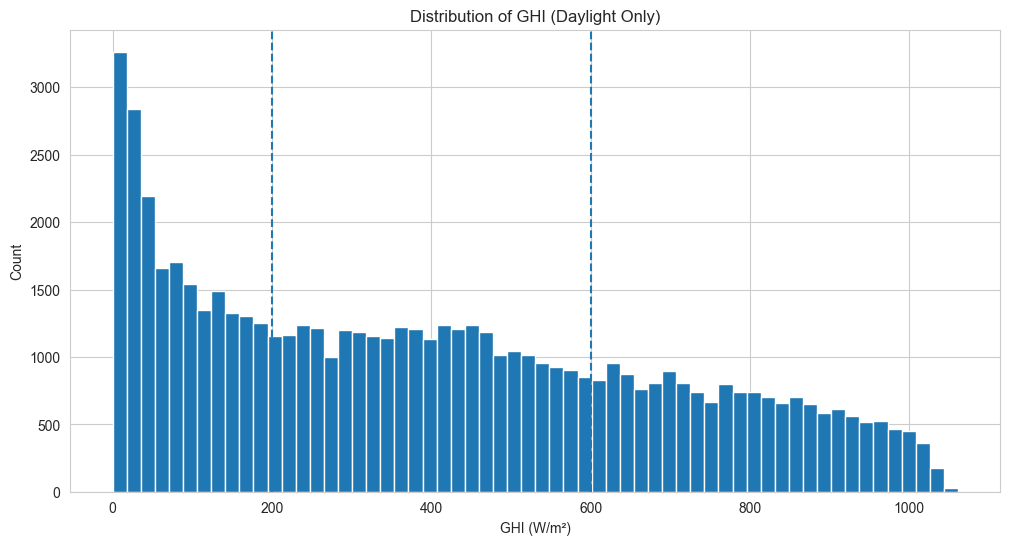


Solar_Class distribution (all):
Solar_Class
0    65.93
1    20.49
2    13.57
Name: proportion, dtype: float64

Solar_Class distribution (daylight only):
Solar_Class
0    32.69
1    40.49
2    26.82
Name: proportion, dtype: float64


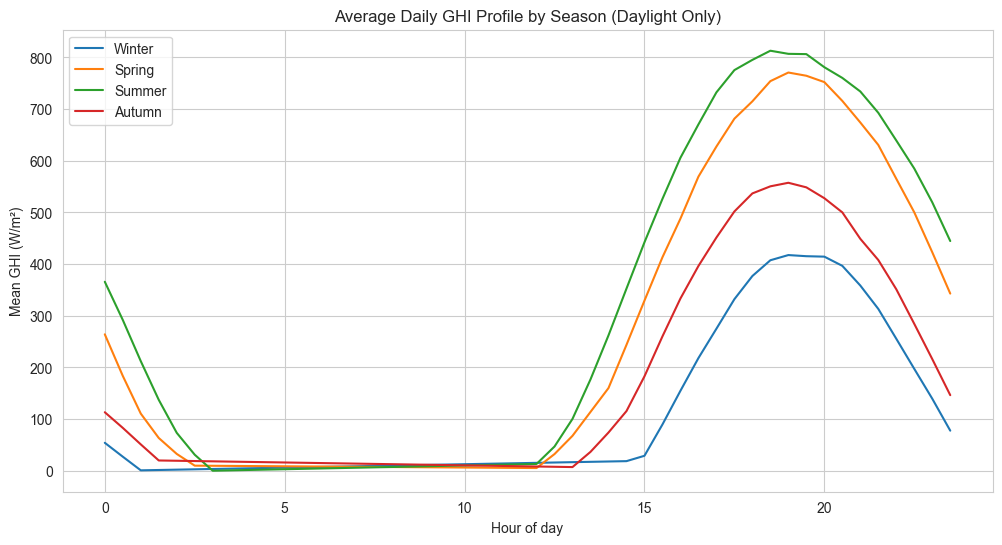

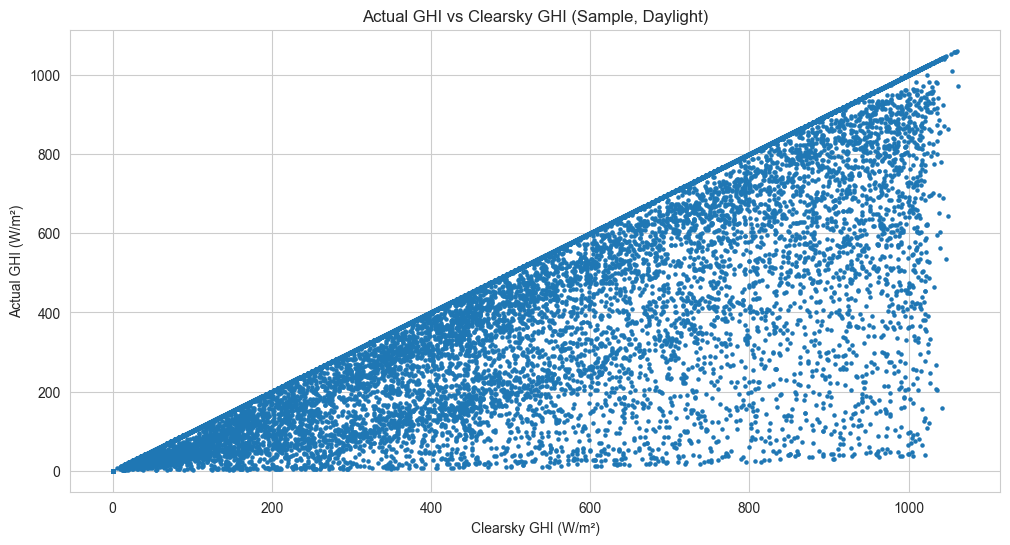

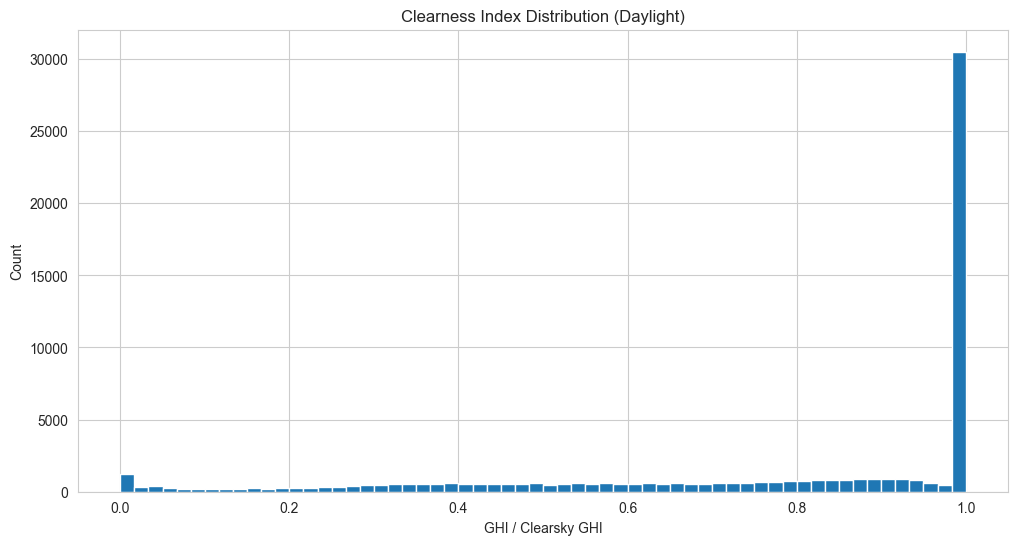


Correlation matrix (daylight):
                      GHI  Clearsky GHI  clearness_index  Temperature  \
GHI                 1.000         0.859            0.558        0.443   
Clearsky GHI        0.859         1.000            0.183        0.462   
clearness_index     0.558         0.183            1.000        0.173   
Temperature         0.443         0.462            0.173        1.000   
Relative Humidity  -0.531        -0.501           -0.298       -0.802   
Pressure            0.203         0.091            0.299        0.567   
Wind Speed         -0.072        -0.031           -0.124       -0.509   
Precipitable Water  0.084         0.202           -0.127        0.724   
Solar Zenith Angle -0.843        -0.989           -0.167       -0.529   
Cloud Type         -0.320        -0.037           -0.617       -0.195   
Dew Point           0.107         0.187           -0.044        0.738   

                    Relative Humidity  Pressure  Wind Speed  \
GHI                         

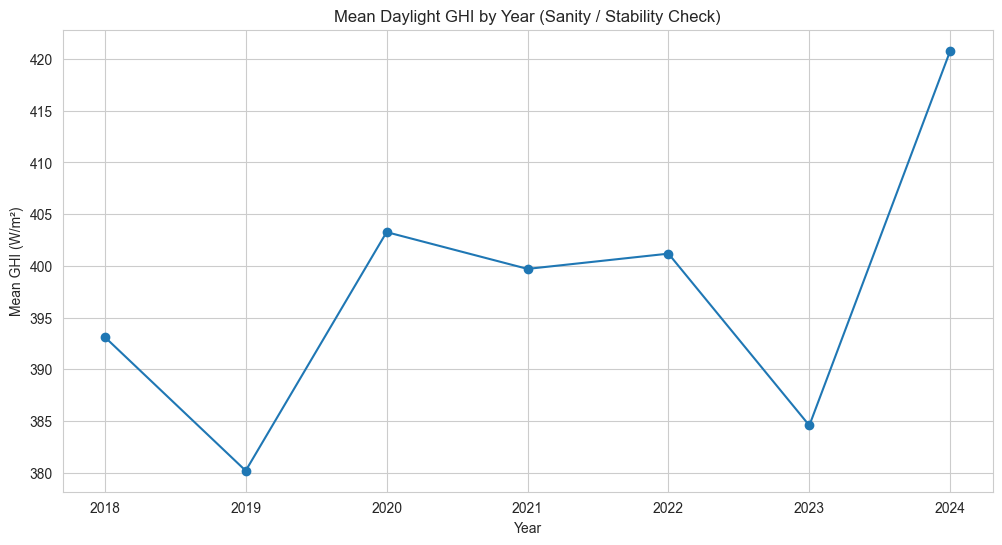

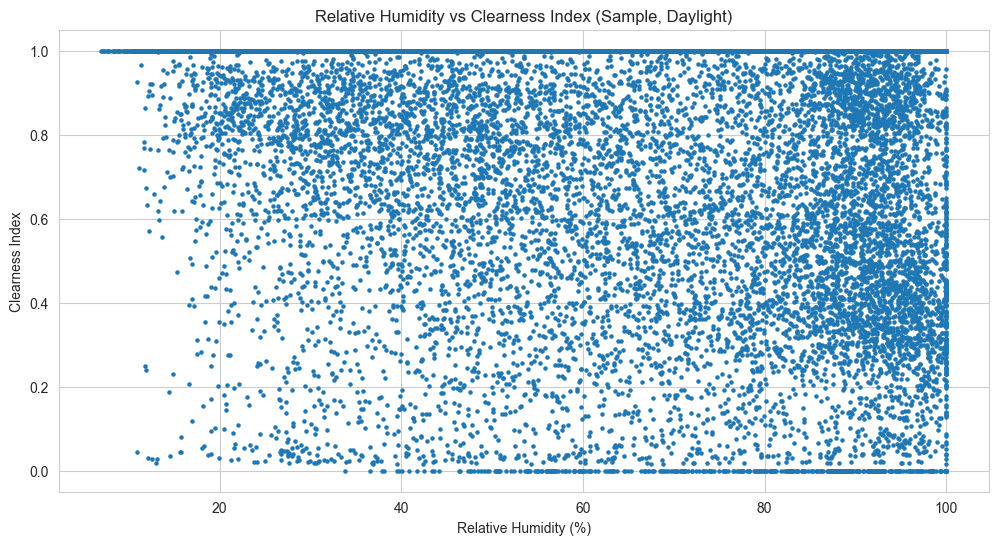


 EDA COMPLETE.
Next step will be: train/validation/test splitting (time-based), then clustering model.


In [ ]:
# STEP 3:  EDA (HIGH-VALUE PLOTS + INSIGHTS)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("data/processed/nsrdb_master_features.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

print("Loaded for EDA:", DATA_PATH.resolve())
print("Shape:", df.shape)


# time features

df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["hour"] = df["timestamp"].dt.hour + df["timestamp"].dt.minute/60.0

# Daylight subset for solar relationships
df_day = df[df["is_daylight"]==1].copy()

print("\nDaylight rows:", len(df_day), " (", round(len(df_day)/len(df)*100,2), "% )")


# EDA-1: Distribution of GHI + thresholds 

plt.figure()
plt.hist(df_day["GHI"], bins=60)
plt.title("Distribution of GHI (Daylight Only)")
plt.xlabel("GHI (W/m²)")
plt.ylabel("Count")
plt.axvline(200, linestyle="--")
plt.axvline(600, linestyle="--")
plt.show()

# Solar_Class distribution across all rows + daylight only
print("\nSolar_Class distribution (all):")
print(df["Solar_Class"].value_counts(normalize=True).sort_index().mul(100).round(2))

print("\nSolar_Class distribution (daylight only):")
print(df_day["Solar_Class"].value_counts(normalize=True).sort_index().mul(100).round(2))


# EDA-2: Typical daily solar curve by season/month 

# Average GHI by hour (daylight only) for each season
def season(m):
    if m in [12,1,2]: return "Winter"
    if m in [3,4,5]: return "Spring"
    if m in [6,7,8]: return "Summer"
    return "Autumn"

df_day["season"] = df_day["month"].apply(season)

hourly_season = df_day.groupby(["season","hour"])["GHI"].mean().reset_index()

plt.figure()
for s in ["Winter","Spring","Summer","Autumn"]:
    sub = hourly_season[hourly_season["season"]==s]
    plt.plot(sub["hour"], sub["GHI"], label=s)
plt.title("Average Daily GHI Profile by Season (Daylight Only)")
plt.xlabel("Hour of day")
plt.ylabel("Mean GHI (W/m²)")
plt.legend()
plt.show()


# EDA-3: Clearsky vs Actual 

# Sample a manageable subset for scatter 
sample = df_day.sample(n=min(20000, len(df_day)), random_state=42)

plt.figure()
plt.scatter(sample["Clearsky GHI"], sample["GHI"], s=5)
plt.title("Actual GHI vs Clearsky GHI (Sample, Daylight)")
plt.xlabel("Clearsky GHI (W/m²)")
plt.ylabel("Actual GHI (W/m²)")
plt.show()

plt.figure()
plt.hist(df_day["clearness_index"], bins=60)
plt.title("Clearness Index Distribution (Daylight)")
plt.xlabel("GHI / Clearsky GHI")
plt.ylabel("Count")
plt.show()


# EDA-4: Correlation heatmap-style table 

eda_cols = [
    "GHI","Clearsky GHI","clearness_index",
    "Temperature","Relative Humidity","Pressure","Wind Speed",
    "Precipitable Water","Solar Zenith Angle","Cloud Type","Dew Point"
]
eda_cols = [c for c in eda_cols if c in df_day.columns]

corr = df_day[eda_cols].corr(numeric_only=True)
print("\nCorrelation matrix (daylight):")
print(corr.round(3))


# EDA-5: Yearly trend 

yearly = df_day.groupby("year")["GHI"].agg(["mean","median","max"]).reset_index()
print("\nYearly GHI summary (daylight):")
print(yearly)

plt.figure()
plt.plot(yearly["year"], yearly["mean"], marker="o")
plt.title("Mean Daylight GHI by Year (Sanity / Stability Check)")
plt.xlabel("Year")
plt.ylabel("Mean GHI (W/m²)")
plt.show()


# EDA-6: Weather regimes hint 

# Relationship: humidity vs clearness
sample2 = df_day.sample(n=min(20000, len(df_day)), random_state=7)

plt.figure()
plt.scatter(sample2["Relative Humidity"], sample2["clearness_index"], s=5)
plt.title("Relative Humidity vs Clearness Index (Sample, Daylight)")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Clearness Index")
plt.show()

print("\n EDA COMPLETE.")
print("Next step will be: train/validation/test splitting (time-based), then clustering model.")


In [ ]:

# STEP 3.5: TIME INTEGRITY + DAYLIGHT-ONLY SUMMARY TABLES 
# - Locate irregular time deltas
# - Fix/report them (drop or reindex)
# - Produce daylight-only descriptive stats for report


import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH = Path("data/processed/nsrdb_master_features.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

print("Loaded:", DATA_PATH.resolve())
print("Shape:", df.shape)
print("Range:", df["timestamp"].min(), "to", df["timestamp"].max())


# 1) Find irregular time steps

delta = df["timestamp"].diff()
expected = pd.Timedelta(minutes=30)

irregular_idx = df.index[delta.notna() & (delta != expected)].tolist()
print("\nExpected step:", expected)
print("Irregular step count:", len(irregular_idx))

if irregular_idx:
    print("\n=== Irregular timestamps (showing context) ===")
    for i in irregular_idx[:10]:
        start = max(i-2, 0)
        end = min(i+3, len(df))
        print("\n--- Context around index", i, "---")
        print(df.loc[start:end, ["timestamp"]].assign(delta=df.loc[start:end, "timestamp"].diff()).to_string(index=True))


# 2) Build a perfect 30-min grid and check missing timestamps

full_index = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq="30min")
df_full = df.set_index("timestamp").reindex(full_index)

missing_count = df_full.isna().all(axis=1).sum()
print("\nFull grid length:", len(full_index))
print("Completely missing rows (true timestamp gaps):", int(missing_count))


# 3) DAYLIGHT-ONLY summary tables

df_day = df[df["is_daylight"] == 1].copy()

print("\n=== DAYLIGHT-ONLY DESCRIPTIVE STATS (REPORT READY) ===")
vars_main = ["GHI","DNI","DHI","Clearsky GHI","clearness_index","cloud_loss",
             "Temperature","Relative Humidity","Pressure","Wind Speed","Precipitable Water",
             "Solar Zenith Angle","Cloud Type","Dew Point"]

vars_main = [c for c in vars_main if c in df_day.columns]

desc = df_day[vars_main].describe().T
desc["missing_rate"] = df_day[vars_main].isna().mean().values
print(desc[["count","mean","std","min","25%","50%","75%","max","missing_rate"]].round(3))


# 4) Clearness index distribution ONLY in daylight

ci = df_day["clearness_index"].dropna()
print("\nDaylight clearness_index percentiles:")
print(ci.quantile([0.05,0.25,0.5,0.75,0.95]).round(3))


# We'll keep original df as master, and create a forecasting-safe version here.
# If there are missing timestamps, we can interpolate only meteorology and keep GHI as NaN (or drop).
forecast_safe_path = Path("data/processed/nsrdb_forecast_regular_index.csv")
df_full_reset = df_full.reset_index().rename(columns={"index":"timestamp"})
df_full_reset.to_csv(forecast_safe_path, index=False)

print("\n Saved forecast-safe reindexed file to:", forecast_safe_path.resolve())


Loaded: C:\Users\Nikhil\Desktop\data mining nikhil\data\processed\nsrdb_master_features.csv
Shape: (122640, 36)
Range: 2018-01-01 00:00:00 to 2024-12-31 23:30:00

Expected step: 0 days 00:30:00
Irregular step count: 2

=== Irregular timestamps (showing context) ===

--- Context around index 37872 ---
                timestamp           delta
37870 2020-02-28 23:00:00             NaT
37871 2020-02-28 23:30:00 0 days 00:30:00
37872 2020-03-01 00:00:00 1 days 00:30:00
37873 2020-03-01 00:30:00 0 days 00:30:00
37874 2020-03-01 01:00:00 0 days 00:30:00
37875 2020-03-01 01:30:00 0 days 00:30:00

--- Context around index 107952 ---
                 timestamp           delta
107950 2024-02-28 23:00:00             NaT
107951 2024-02-28 23:30:00 0 days 00:30:00
107952 2024-03-01 00:00:00 1 days 00:30:00
107953 2024-03-01 00:30:00 0 days 00:30:00
107954 2024-03-01 01:00:00 0 days 00:30:00
107955 2024-03-01 01:30:00 0 days 00:30:00

Full grid length: 122736
Completely missing rows (true timestamp 

In [ ]:

# STEP 4: FINAL TIME INTEGRITY + TRAIN/VAL/TEST SPLITS (TIME-BASED)
# - Confirms leap-day gaps explicitly
# - Builds strict 30-min regular index dataset for forecasting
# - Creates time-based splits (train/val/test) with NO leakage


import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH = Path("data/processed/nsrdb_master_features.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

print("Loaded:", DATA_PATH.resolve())
print("Shape:", df.shape)
print("Range:", df["timestamp"].min(), "to", df["timestamp"].max())


# 1) Build full regular 30-min grid and identify missing timestamps

freq = "30min"
full_index = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq=freq)

df_full = df.set_index("timestamp").reindex(full_index)
missing_ts = df_full.index[df_full.isna().all(axis=1)]

print("\n=== REGULAR GRID CHECK ===")
print("Full grid length:", len(full_index))
print("Missing timestamps count:", len(missing_ts))

# Show missing timestamps grouped by date
if len(missing_ts) > 0:
    missing_dates = pd.Series(missing_ts.date).value_counts().sort_index()
    print("\nMissing dates (count per date):")
    print(missing_dates)

    print("\nFirst 10 missing timestamps:")
    print(missing_ts[:10])
    print("\nLast 10 missing timestamps:")
    print(missing_ts[-10:])


# 2) Save strict regular-index dataset (forecast-safe)
#    We keep NaNs for missing times to avoid injecting fake solar values.

forecast_safe = df_full.reset_index().rename(columns={"index": "timestamp"})
OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

forecast_path = OUT_DIR / "nsrdb_forecast_regular_30min.csv"
forecast_safe.to_csv(forecast_path, index=False)
print("\n Saved strict regular-index dataset to:", forecast_path.resolve())


# 3) Create time-based splits (recommended for your project)
#    Train: 2018-2022, Val: 2023, Test: 2024

df["year"] = df["timestamp"].dt.year

train = df[(df["year"] >= 2018) & (df["year"] <= 2022)].copy()
val   = df[df["year"] == 2023].copy()
test  = df[df["year"] == 2024].copy()

print("\n=== TIME SPLITS ===")
print("Train years:", train["year"].unique(), "| shape:", train.shape, "| range:", train["timestamp"].min(), "to", train["timestamp"].max())
print("Val years:", val["year"].unique(), "| shape:", val.shape, "| range:", val["timestamp"].min(), "to", val["timestamp"].max())
print("Test years:", test["year"].unique(), "| shape:", test.shape, "| range:", test["timestamp"].min(), "to", test["timestamp"].max())

# Save split files (useful for clean workflow + marks)
train_path = OUT_DIR / "train_2018_2022.csv"
val_path   = OUT_DIR / "val_2023.csv"
test_path  = OUT_DIR / "test_2024.csv"

train.to_csv(train_path, index=False)
val.to_csv(val_path, index=False)
test.to_csv(test_path, index=False)

print("\n Saved split datasets:")
print(" -", train_path.resolve())
print(" -", val_path.resolve())
print(" -", test_path.resolve())


# 4) Split versions specifically for clustering (daylight only)

cluster_features = [
    "Temperature","Relative Humidity","Pressure","Wind Speed","Wind Direction",
    "Precipitable Water","Dew Point","Aerosol Optical Depth","SSA","Ozone"
]
cluster_features = [c for c in cluster_features if c in df.columns]

train_cluster = train[train["is_daylight"]==1].dropna(subset=cluster_features + ["GHI"]).copy()
val_cluster   = val[val["is_daylight"]==1].dropna(subset=cluster_features + ["GHI"]).copy()
test_cluster  = test[test["is_daylight"]==1].dropna(subset=cluster_features + ["GHI"]).copy()

print("\n=== CLUSTER SPLITS (DAYLIGHT) ===")
print("Train_cluster:", train_cluster.shape)
print("Val_cluster:", val_cluster.shape)
print("Test_cluster:", test_cluster.shape)

# Report-ready statement
print("\n=== REPORT READY NOTE ===")
if len(missing_ts) == 96:
    print("Detected 96 missing timestamps, consistent with two missing leap days (29-Feb 2020 and 29-Feb 2024) at 30-minute resolution (48 intervals/day).")
else:
    print("Missing timestamps detected:", len(missing_ts), "(review missing_dates table above).")


Loaded: C:\Users\Nikhil\Desktop\data mining nikhil\data\processed\nsrdb_master_features.csv
Shape: (122640, 36)
Range: 2018-01-01 00:00:00 to 2024-12-31 23:30:00

=== REGULAR GRID CHECK ===
Full grid length: 122736
Missing timestamps count: 96

Missing dates (count per date):
2020-02-29    48
2024-02-29    48
Name: count, dtype: int64

First 10 missing timestamps:
DatetimeIndex(['2020-02-29 00:00:00', '2020-02-29 00:30:00',
               '2020-02-29 01:00:00', '2020-02-29 01:30:00',
               '2020-02-29 02:00:00', '2020-02-29 02:30:00',
               '2020-02-29 03:00:00', '2020-02-29 03:30:00',
               '2020-02-29 04:00:00', '2020-02-29 04:30:00'],
              dtype='datetime64[ns]', freq=None)

Last 10 missing timestamps:
DatetimeIndex(['2024-02-29 19:00:00', '2024-02-29 19:30:00',
               '2024-02-29 20:00:00', '2024-02-29 20:30:00',
               '2024-02-29 21:00:00', '2024-02-29 21:30:00',
               '2024-02-29 22:00:00', '2024-02-29 22:30:00',
     

Clustering (K-Means) with k-selection + interpretation

In [ ]:

# STEP 5: MODEL 1 - CLUSTERING (K-MEANS) WITH K-SELECTION + INTERPRETATION
# - Uses train_cluster (daylight only) to learn regimes
# - Chooses k with elbow (inertia) + silhouette
# - Interprets clusters by linking to GHI & clearness_index (NOT used in clustering)


import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Load split datasets (train/val/test) and filter daylight for clustering

train = pd.read_csv("data/processed/train_2018_2022.csv", parse_dates=["timestamp"])
val   = pd.read_csv("data/processed/val_2023.csv", parse_dates=["timestamp"])
test  = pd.read_csv("data/processed/test_2024.csv", parse_dates=["timestamp"])

cluster_features = [
    "Temperature","Relative Humidity","Pressure","Wind Speed","Wind Direction",
    "Precipitable Water","Dew Point","Aerosol Optical Depth","SSA","Ozone"
]
cluster_features = [c for c in cluster_features if c in train.columns]

train_c = train[train["is_daylight"]==1].dropna(subset=cluster_features + ["GHI","clearness_index"]).copy()
val_c   = val[val["is_daylight"]==1].dropna(subset=cluster_features + ["GHI","clearness_index"]).copy()
test_c  = test[test["is_daylight"]==1].dropna(subset=cluster_features + ["GHI","clearness_index"]).copy()

print("=== DATASETS ===")
print("Cluster features:", cluster_features)
print("Train_cluster shape:", train_c.shape)
print("Val_cluster shape:", val_c.shape)
print("Test_cluster shape:", test_c.shape)

X_train = train_c[cluster_features].values
X_val   = val_c[cluster_features].values
X_test  = test_c[cluster_features].values


# 1) Standardize features

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)


# 2) Select k using inertia + silhouette (train only)

k_values = list(range(2, 11))  # 2..10 (good for report)
rows = []

print("\n=== K-SELECTION (TRAIN ONLY) ===")
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_train_s)
    inertia = km.inertia_
    sil = silhouette_score(X_train_s, labels)
    rows.append({"k": k, "inertia": inertia, "silhouette_train": sil})

k_table = pd.DataFrame(rows).sort_values("k")
print(k_table.to_string(index=False))

best_k = int(k_table.sort_values("silhouette_train", ascending=False).iloc[0]["k"])
best_sil = float(k_table.sort_values("silhouette_train", ascending=False).iloc[0]["silhouette_train"])
print(f"\nBest k by silhouette on train: k={best_k} (silhouette={best_sil:.4f})")


# 3) Fit final KMeans on train with best_k

final_km = KMeans(n_clusters=best_k, random_state=42, n_init=50)
train_c["cluster"] = final_km.fit_predict(X_train_s)
val_c["cluster"]   = final_km.predict(X_val_s)
test_c["cluster"]  = final_km.predict(X_test_s)

# Validate stability (silhouette on val/test)
val_sil  = silhouette_score(X_val_s, val_c["cluster"])
test_sil = silhouette_score(X_test_s, test_c["cluster"])

print("\n=== STABILITY CHECK ===")
print(f"Silhouette (train): {best_sil:.4f}")
print(f"Silhouette (val):   {val_sil:.4f}")
print(f"Silhouette (test):  {test_sil:.4f}")


# 4) Interpret clusters using OUTCOME variables (GHI, clearness_index)
#    IMPORTANT: GHI was NOT used to form clusters; it is used only for labeling.

interpret_cols = cluster_features + [
    "GHI","clearness_index","cloud_loss","Relative Humidity","Cloud Type","Solar Zenith Angle","Temperature"
]
interpret_cols = [c for c in interpret_cols if c in train_c.columns]

profile = train_c.groupby("cluster")[interpret_cols].agg(["mean","median","std","count"])
# Flatten columns for easy viewing
profile.columns = ["_".join(col).strip() for col in profile.columns.values]
profile = profile.reset_index()

# Make a compact "key metrics" table for report
key_metrics = ["cluster",
               "GHI_mean","GHI_median",
               "clearness_index_mean","clearness_index_median",
               "cloud_loss_mean",
               "Relative Humidity_mean",
               "Temperature_mean",
               "Precipitable Water_mean" if "Precipitable Water_mean" in profile.columns else None,
               "Cloud Type_mean" if "Cloud Type_mean" in profile.columns else None,
               "count_count"]
key_metrics = [c for c in key_metrics if c is not None and c in profile.columns]

compact = profile[key_metrics].sort_values("GHI_mean", ascending=False)

print("\n=== CLUSTER PROFILE (TRAIN, SORTED BY MEAN GHI) ===")
print(compact.to_string(index=False))

# 5) Save clustering outputs for later use in classification/forecasting analysis
OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

train_c.to_csv(OUT_DIR / "train_cluster_labeled.csv", index=False)
val_c.to_csv(OUT_DIR / "val_cluster_labeled.csv", index=False)
test_c.to_csv(OUT_DIR / "test_cluster_labeled.csv", index=False)

print("\n Saved labeled cluster datasets:")
print(" - train_cluster_labeled.csv")
print(" - val_cluster_labeled.csv")
print(" - test_cluster_labeled.csv")



=== DATASETS ===
Cluster features: ['Temperature', 'Relative Humidity', 'Pressure', 'Wind Speed', 'Wind Direction', 'Precipitable Water', 'Dew Point', 'Aerosol Optical Depth', 'SSA', 'Ozone']
Train_cluster shape: (44334, 37)
Val_cluster shape: (8871, 37)
Test_cluster shape: (8864, 37)

=== K-SELECTION (TRAIN ONLY) ===
 k       inertia  silhouette_train
 2 307852.360621          0.277206
 3 272856.250050          0.210185
 4 248192.080147          0.167643
 5 224692.471036          0.176463
 6 206940.335758          0.175075
 7 195162.256537          0.176632
 8 187085.420355          0.169823
 9 179686.703427          0.145756
10 172934.292482          0.145240

Best k by silhouette on train: k=2 (silhouette=0.2772)

=== STABILITY CHECK ===
Silhouette (train): 0.2772
Silhouette (val):   0.3171
Silhouette (test):  0.2959

=== CLUSTER PROFILE (TRAIN, SORTED BY MEAN GHI) ===
 cluster   GHI_mean  GHI_median  clearness_index_mean  clearness_index_median  cloud_loss_mean  Relative Humidity_m

=== CLUSTER PROPORTIONS (%) ===
split     test  train    val
cluster                     
0        44.62   49.8  45.33
1        55.38   50.2  54.67

=== REGIME PROFILE (TRAIN) ===
   cluster  GHI_mean  clearness_mean  RH_mean  Temp_mean  cloud_loss_mean  \
0        1   473.877           0.835   41.579     16.246           83.940   
1        0   316.473           0.713   78.270     -3.557          102.077   

   CloudType_mean  
0           2.493  
1           3.946  

Regime naming:
Cluster 1 -> Regime A: Clear / High-Efficiency
Cluster 0 -> Regime B: Humid / Low-Efficiency

 Saved named regime files:
 - train_cluster_named.csv
 - val_cluster_named.csv
 - test_cluster_named.csv


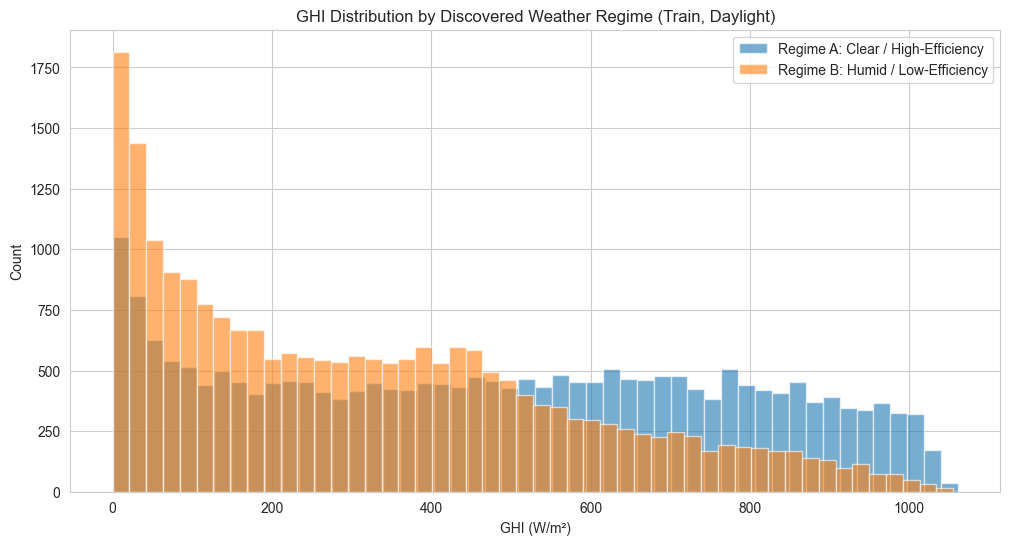

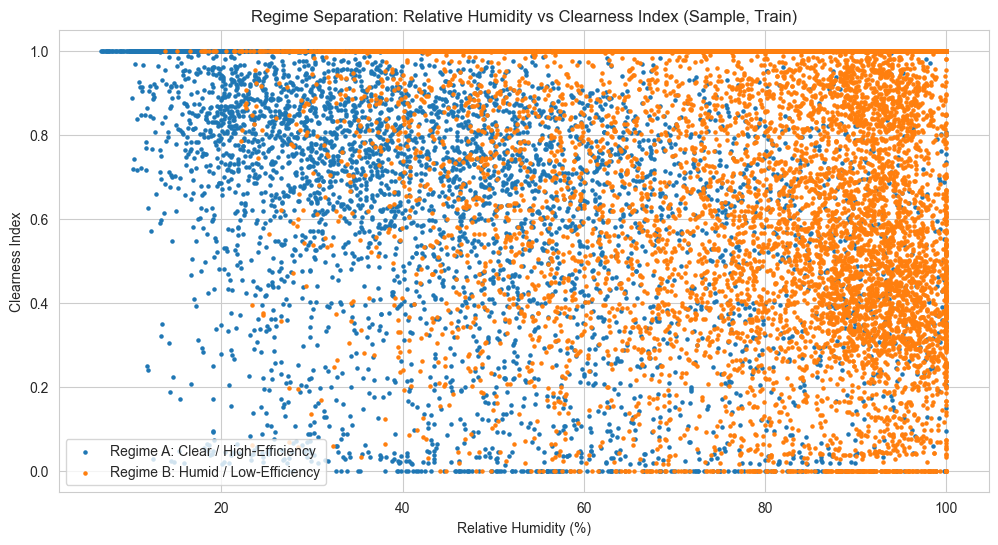

In [ ]:

# STEP 5B: CLUSTER REGIME NAMING + STABILITY + PLOTS 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the labeled clusters
train_c = pd.read_csv("data/processed/train_cluster_labeled.csv", parse_dates=["timestamp"])
val_c   = pd.read_csv("data/processed/val_cluster_labeled.csv", parse_dates=["timestamp"])
test_c  = pd.read_csv("data/processed/test_cluster_labeled.csv", parse_dates=["timestamp"])


# 1) Cluster proportions across splits (stability check)

def cluster_props(df, name):
    props = df["cluster"].value_counts(normalize=True).sort_index()
    props = (props * 100).round(2)
    return pd.DataFrame({"split": name, "cluster": props.index, "pct": props.values})

props_df = pd.concat([
    cluster_props(train_c, "train"),
    cluster_props(val_c, "val"),
    cluster_props(test_c, "test")
], ignore_index=True)

print("=== CLUSTER PROPORTIONS (%) ===")
print(props_df.pivot(index="cluster", columns="split", values="pct"))


# 2) Create regime names based on GHI mean (higher = high-efficiency)

profile = train_c.groupby("cluster").agg(
    GHI_mean=("GHI","mean"),
    clearness_mean=("clearness_index","mean"),
    RH_mean=("Relative Humidity","mean"),
    Temp_mean=("Temperature","mean"),
    cloud_loss_mean=("cloud_loss","mean"),
    CloudType_mean=("Cloud Type","mean")
).reset_index()

profile = profile.sort_values("GHI_mean", ascending=False).reset_index(drop=True)

# Highest GHI cluster -> High efficiency
high_cluster = int(profile.loc[0, "cluster"])
low_cluster  = int(profile.loc[1, "cluster"])

name_map = {
    high_cluster: "Regime A: Clear / High-Efficiency",
    low_cluster:  "Regime B: Humid / Low-Efficiency"
}

train_c["regime_name"] = train_c["cluster"].map(name_map)
val_c["regime_name"]   = val_c["cluster"].map(name_map)
test_c["regime_name"]  = test_c["cluster"].map(name_map)

print("\n=== REGIME PROFILE (TRAIN) ===")
print(profile.round(3))

print("\nRegime naming:")
for k,v in name_map.items():
    print(f"Cluster {k} -> {v}")

# Save renamed files
train_c.to_csv("data/processed/train_cluster_named.csv", index=False)
val_c.to_csv("data/processed/val_cluster_named.csv", index=False)
test_c.to_csv("data/processed/test_cluster_named.csv", index=False)

print("\n Saved named regime files:")
print(" - train_cluster_named.csv")
print(" - val_cluster_named.csv")
print(" - test_cluster_named.csv")


# 3) Plot: GHI distribution by regime (report figure)

plt.figure()
for nm in sorted(train_c["regime_name"].unique()):
    sub = train_c[train_c["regime_name"] == nm]["GHI"]
    plt.hist(sub, bins=50, alpha=0.6, label=nm)
plt.title("GHI Distribution by Discovered Weather Regime (Train, Daylight)")
plt.xlabel("GHI (W/m²)")
plt.ylabel("Count")
plt.legend()
plt.show()


# 4) Plot: RH vs clearness_index scatter (regime separation)

sample = train_c.sample(n=min(20000, len(train_c)), random_state=42)

plt.figure()
for nm in sorted(sample["regime_name"].unique()):
    ss = sample[sample["regime_name"] == nm]
    plt.scatter(ss["Relative Humidity"], ss["clearness_index"], s=5, label=nm)
plt.title("Regime Separation: Relative Humidity vs Clearness Index (Sample, Train)")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Clearness Index")
plt.legend()
plt.show()



Classification + Hyperparameter Tuning

In [ ]:

# STEP 6: MODEL 2 - CLASSIFICATION (Solar_Class: 0/1/2)
# - Train: 2018-2022 | Val: 2023 | Test: 2024
# - Inputs: meteorology only (NO irradiance features)
# - Baseline RF + RandomizedSearch tuning
# - Metrics: accuracy, macro-F1, confusion matrix, class report
# - Feature importance
# 


import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)


# Load split datasets

train = pd.read_csv("data/processed/train_2018_2022.csv", parse_dates=["timestamp"])
val   = pd.read_csv("data/processed/val_2023.csv", parse_dates=["timestamp"])
test  = pd.read_csv("data/processed/test_2024.csv", parse_dates=["timestamp"])


# 1) Define FEATURES (no irradiance) + TARGET

# Keeping it aligned with  "cheap sensors" narrative.
features = [
    "Temperature","Relative Humidity","Pressure","Wind Speed",
    "Wind Direction","Precipitable Water","Dew Point",
    "Aerosol Optical Depth","SSA","Ozone",
    "Solar Zenith Angle","Cloud Type"
]
features = [c for c in features if c in train.columns]

target = "Solar_Class"

print("Features used (count={}):".format(len(features)))
print(features)

# Drop rows with missing 
train_m = train.dropna(subset=features + [target]).copy()
val_m   = val.dropna(subset=features + [target]).copy()
test_m  = test.dropna(subset=features + [target]).copy()

X_train, y_train = train_m[features], train_m[target].astype(int)
X_val,   y_val   = val_m[features],   val_m[target].astype(int)
X_test,  y_test  = test_m[features],  test_m[target].astype(int)

print("\nShapes:")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


# 2) Baseline RandomForest

baseline = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
baseline.fit(X_train, y_train)

val_pred = baseline.predict(X_val)
test_pred = baseline.predict(X_test)

print("\n=== BASELINE RF (no tuning) ===")
print("VAL  Accuracy:", round(accuracy_score(y_val, val_pred), 4),
      "| Macro-F1:", round(f1_score(y_val, val_pred, average="macro"), 4))
print("TEST Accuracy:", round(accuracy_score(y_test, test_pred), 4),
      "| Macro-F1:", round(f1_score(y_test, test_pred, average="macro"), 4))

print("\nConfusion Matrix (TEST):")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report (TEST):")
print(classification_report(y_test, test_pred, digits=4))


# 3) Hyperparameter tuning (RandomizedSearchCV)

param_dist = {
    "n_estimators": [300, 500, 800],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=25,                
    scoring="f1_macro",       
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

print("\n=== TUNING (RandomizedSearchCV) ===")
search.fit(X_train, y_train)

best_rf = search.best_estimator_
print("\nBest Params:")
print(search.best_params_)
print("Best CV Macro-F1:", round(search.best_score_, 4))

# Evaluate tuned model
val_pred_t = best_rf.predict(X_val)
test_pred_t = best_rf.predict(X_test)

print("\n=== TUNED RF ===")
print("VAL  Accuracy:", round(accuracy_score(y_val, val_pred_t), 4),
      "| Macro-F1:", round(f1_score(y_val, val_pred_t, average='macro'), 4))
print("TEST Accuracy:", round(accuracy_score(y_test, test_pred_t), 4),
      "| Macro-F1:", round(f1_score(y_test, test_pred_t, average='macro'), 4))

print("\nConfusion Matrix (TEST, tuned):")
print(confusion_matrix(y_test, test_pred_t))

print("\nClassification Report (TEST, tuned):")
print(classification_report(y_test, test_pred_t, digits=4))


# 4) Feature importance (top 10)

importances = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=False)

print("\n=== FEATURE IMPORTANCE (Top 12) ===")
print(importances.head(12).round(5))


# 5) evaluate on daylight-only subset

test_day = test_m[test_m["is_daylight"] == 1].copy()
X_test_day = test_day[features]
y_test_day = test_day[target].astype(int)

pred_day = best_rf.predict(X_test_day)

print("\n=== DAYLIGHT-ONLY PERFORMANCE (TEST 2024) ===")
print("Accuracy:", round(accuracy_score(y_test_day, pred_day), 4),
      "| Macro-F1:", round(f1_score(y_test_day, pred_day, average="macro"), 4))

print("\nConfusion Matrix (Daylight only):")
print(confusion_matrix(y_test_day, pred_day))

print("\nClassification Report (Daylight only):")
print(classification_report(y_test_day, pred_day, digits=4))

print("\n NEXT: Model 3 Forecasting (ARIMA baseline vs LSTM/GRU) with walk-forward validation.")


Features used (count=12):
['Temperature', 'Relative Humidity', 'Pressure', 'Wind Speed', 'Wind Direction', 'Precipitable Water', 'Dew Point', 'Aerosol Optical Depth', 'SSA', 'Ozone', 'Solar Zenith Angle', 'Cloud Type']

Shapes:
Train: (87600, 12) Val: (17520, 12) Test: (17520, 12)

=== BASELINE RF (no tuning) ===
VAL  Accuracy: 0.9163 | Macro-F1: 0.8772
TEST Accuracy: 0.9301 | Macro-F1: 0.9015

Confusion Matrix (TEST):
[[11018   222    23]
 [  526  3002   130]
 [    2   322  2275]]

Classification Report (TEST):
              precision    recall  f1-score   support

           0     0.9543    0.9782    0.9661     11263
           1     0.8466    0.8207    0.8334      3658
           2     0.9370    0.8753    0.9051      2599

    accuracy                         0.9301     17520
   macro avg     0.9126    0.8914    0.9015     17520
weighted avg     0.9292    0.9301    0.9294     17520


=== TUNING (RandomizedSearchCV) ===
Fitting 3 folds for each of 25 candidates, totalling 75 fits

Be

In [34]:

# STEP 6B:  STUDY
# Compare:
#  A) Full features (includes Solar Zenith Angle)
#  B) Weather-only features (removes Solar Zenith Angle)


import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Load splits
train = pd.read_csv("data/processed/train_2018_2022.csv", parse_dates=["timestamp"])
val   = pd.read_csv("data/processed/val_2023.csv", parse_dates=["timestamp"])
test  = pd.read_csv("data/processed/test_2024.csv", parse_dates=["timestamp"])

target = "Solar_Class"

full_features = [
    "Temperature","Relative Humidity","Pressure","Wind Speed","Wind Direction",
    "Precipitable Water","Dew Point","Aerosol Optical Depth","SSA","Ozone",
    "Solar Zenith Angle","Cloud Type"
]
full_features = [c for c in full_features if c in train.columns]

weather_only = [c for c in full_features if c != "Solar Zenith Angle"]

# Tuned params from your search
params = dict(
    n_estimators=800,
    min_samples_split=20,
    min_samples_leaf=2,
    max_features=None,
    max_depth=40,
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

def train_eval(feats, name):
    tr = train.dropna(subset=feats + [target]).copy()
    te = test.dropna(subset=feats + [target]).copy()

    Xtr, ytr = tr[feats], tr[target].astype(int)
    Xte, yte = te[feats], te[target].astype(int)

    model = RandomForestClassifier(**params)
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)

    acc = accuracy_score(yte, pred)
    mf1 = f1_score(yte, pred, average="macro")

    print(f"\n=== {name} ===")
    print("Features count:", len(feats))
    print("TEST Accuracy:", round(acc, 4), "| Macro-F1:", round(mf1, 4))
    print("Confusion Matrix (TEST):")
    print(confusion_matrix(yte, pred))
    print("\nClassification Report (TEST):")
    print(classification_report(yte, pred, digits=4))

    return model

m_full = train_eval(full_features, "MODEL A: Full (with Solar Zenith Angle)")
m_weather = train_eval(weather_only, "MODEL B: Weather-only (NO Solar Zenith Angle)")



=== MODEL A: Full (with Solar Zenith Angle) ===
Features count: 12
TEST Accuracy: 0.9485 | Macro-F1: 0.9276
Confusion Matrix (TEST):
[[10961   280    22]
 [  239  3284   135]
 [    0   227  2372]]

Classification Report (TEST):
              precision    recall  f1-score   support

           0     0.9787    0.9732    0.9759     11263
           1     0.8663    0.8978    0.8817      3658
           2     0.9379    0.9127    0.9251      2599

    accuracy                         0.9485     17520
   macro avg     0.9276    0.9279    0.9276     17520
weighted avg     0.9491    0.9485    0.9487     17520


=== MODEL B: Weather-only (NO Solar Zenith Angle) ===
Features count: 11
TEST Accuracy: 0.6955 | Macro-F1: 0.6367
Confusion Matrix (TEST):
[[8639 2555   69]
 [1159 2020  479]
 [ 235  837 1527]]

Classification Report (TEST):
              precision    recall  f1-score   support

           0     0.8611    0.7670    0.8113     11263
           1     0.3732    0.5522    0.4454      3658
 

In [ ]:

# STEP 7A: FORECASTING SETUP , BASELINES , LAG FEATURES
# Forecast targets:
#  - 30-min ahead: GHI(t+1)
#  - 24h ahead:   GHI(t+48) because 30min data => 48 steps per day
# Splits:
#  - Train: 2018-2022
#  - Val:   2023
#  - Test:  2024


import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score


#  Load splits

train = pd.read_csv("data/processed/train_2018_2022.csv", parse_dates=["timestamp"]).sort_values("timestamp")
val   = pd.read_csv("data/processed/val_2023.csv", parse_dates=["timestamp"]).sort_values("timestamp")
test  = pd.read_csv("data/processed/test_2024.csv", parse_dates=["timestamp"]).sort_values("timestamp")

# We'll compute BOTH (report both: "all-hours" and "daylight-only").
def eval_reg(y_true, y_pred, label):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"label": label, "RMSE": rmse, "MAE": mae, "R2": r2}


# 1) horizons

H1 = 1    # 30 minutes ahead
H24 = 48  # 24 hours ahead (48 * 30min)


# 2) Baseline models (use only past GHI)

def make_baselines(df, horizon):
    df = df.copy()
    df["y_true"] = df["GHI"].shift(-horizon)
    df["pred_persist"] = df["GHI"]                # predict next as current
    df["pred_seasonal"] = df["GHI"].shift(48)     # predict as same time yesterday
    # Keep only rows where all defined
    out = df.dropna(subset=["y_true","pred_persist","pred_seasonal"])
    return out

def baseline_report(split_name, df, horizon):
    b = make_baselines(df, horizon)
    res = []
    res.append(eval_reg(b["y_true"], b["pred_persist"], f"{split_name} H={horizon} persistence"))
    res.append(eval_reg(b["y_true"], b["pred_seasonal"], f"{split_name} H={horizon} seasonal(t-24h)"))
    return res

# All-hours baseline
results = []
results += baseline_report("VAL(all)", val, H1)
results += baseline_report("TEST(all)", test, H1)
results += baseline_report("VAL(all)", val, H24)
results += baseline_report("TEST(all)", test, H24)

# Daylight-only baseline (filter by is_daylight==1 BEFORE shifting)
val_day = val[val["is_daylight"]==1].copy()
test_day = test[test["is_daylight"]==1].copy()
results += baseline_report("VAL(daylight)", val_day, H1)
results += baseline_report("TEST(daylight)", test_day, H1)
results += baseline_report("VAL(daylight)", val_day, H24)
results += baseline_report("TEST(daylight)", test_day, H24)

baseline_df = pd.DataFrame(results)
print("=== BASELINE RESULTS ===")
print(baseline_df.sort_values("label").to_string(index=False))


# 3) Build supervised lag features (for ML + LSTM)
# We'll build a "forecasting table" with:
#  - target y(t+h)
#  - lags: GHI(t-1), GHI(t-2), ..., GHI(t-48)
#  - exogenous meteo at time t: Temperature, RH, Pressure, PW, CloudType, Zenith, ClearskyGHI

base_features = [
    "GHI","Clearsky GHI","Temperature","Relative Humidity","Pressure",
    "Wind Speed","Precipitable Water","Cloud Type","Solar Zenith Angle"
]
base_features = [c for c in base_features if c in train.columns]

def make_lagged(df, horizon, lags=(1,2,3,6,12,24,48)):
    d = df.copy()
    # target
    d[f"y_t_plus_{horizon}"] = d["GHI"].shift(-horizon)
    # lags
    for L in lags:
        d[f"GHI_lag_{L}"] = d["GHI"].shift(L)
    # keep current exogenous
    keep_cols = ["timestamp","is_daylight"] + base_features + [f"y_t_plus_{horizon}"] + [f"GHI_lag_{L}" for L in lags]
    d = d[keep_cols].dropna()
    return d

lags = (1,2,3,6,12,24,48)

train_h1 = make_lagged(train, H1, lags=lags)
val_h1   = make_lagged(val, H1, lags=lags)
test_h1  = make_lagged(test, H1, lags=lags)

train_h24 = make_lagged(train, H24, lags=lags)
val_h24   = make_lagged(val, H24, lags=lags)
test_h24  = make_lagged(test, H24, lags=lags)

print("\n=== LAGGED DATASET SHAPES ===")
print("H=1  train/val/test:", train_h1.shape, val_h1.shape, test_h1.shape)
print("H=48 train/val/test:", train_h24.shape, val_h24.shape, test_h24.shape)

print("\nFeature columns for ML:")
feature_cols = [c for c in train_h1.columns if c not in ["timestamp","is_daylight", f"y_t_plus_{H1}"]]
print(feature_cols)

# Save lagged datasets ( for next steps)
train_h1.to_csv("data/processed/forecast_h1_train.csv", index=False)
val_h1.to_csv("data/processed/forecast_h1_val.csv", index=False)
test_h1.to_csv("data/processed/forecast_h1_test.csv", index=False)

train_h24.to_csv("data/processed/forecast_h48_train.csv", index=False)
val_h24.to_csv("data/processed/forecast_h48_val.csv", index=False)
test_h24.to_csv("data/processed/forecast_h48_test.csv", index=False)

print("\n Saved lagged forecasting tables:")
print(" - forecast_h1_train/val/test.csv")
print(" - forecast_h48_train/val/test.csv")


=== BASELINE RESULTS ===
                              label       RMSE        MAE        R2
          TEST(all) H=1 persistence  83.257097  43.131933  0.921122
      TEST(all) H=1 seasonal(t-24h) 128.655769  63.245779  0.811647
         TEST(all) H=48 persistence 120.601051  47.357495  0.834744
     TEST(all) H=48 seasonal(t-24h) 126.020917  51.548496  0.819556
     TEST(daylight) H=1 persistence 116.989979  84.349631  0.841201
 TEST(daylight) H=1 seasonal(t-24h) 405.361767 325.679977 -0.906500
    TEST(daylight) H=48 persistence 420.292807 336.098426 -1.045387
TEST(daylight) H=48 seasonal(t-24h) 393.001463 313.942404 -0.788381
           VAL(all) H=1 persistence  99.748671  48.035774  0.872105
       VAL(all) H=1 seasonal(t-24h) 147.988283  71.312174  0.718489
          VAL(all) H=48 persistence 140.997326  58.169479  0.744906
      VAL(all) H=48 seasonal(t-24h) 149.923245  64.513946  0.711586
      VAL(daylight) H=1 persistence 140.263547  94.270007  0.755262
  VAL(daylight) H=1 sea

In [ ]:

# STEP 7A: CORRECT DAYLIGHT-ONLY EVALUATION FOR BASELINES
#  generate predictions on the full time series,
# then filter the evaluation rows to daylight-only.


import pandas as pd
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def eval_reg(y_true, y_pred):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, r2

def baseline_table(df, split_name):
    out = []

    for horizon, tag in [(1, "H=1"), (48, "H=48")]:
        d = df.sort_values("timestamp").copy()
        d["y_true"] = d["GHI"].shift(-horizon)
        d["pred_persist"] = d["GHI"]
        d["pred_seasonal"] = d["GHI"].shift(48)

        d = d.dropna(subset=["y_true","pred_persist","pred_seasonal","is_daylight"])

        # all-hours
        rmse, mae, r2 = eval_reg(d["y_true"], d["pred_persist"])
        out.append([f"{split_name} all {tag} persistence", rmse, mae, r2])

        rmse, mae, r2 = eval_reg(d["y_true"], d["pred_seasonal"])
        out.append([f"{split_name} all {tag} seasonal(t-24h)", rmse, mae, r2])

        # daylight-only evaluation (filter AFTER shifts)
        dd = d[d["is_daylight"] == 1].copy()

        rmse, mae, r2 = eval_reg(dd["y_true"], dd["pred_persist"])
        out.append([f"{split_name} daylight {tag} persistence", rmse, mae, r2])

        rmse, mae, r2 = eval_reg(dd["y_true"], dd["pred_seasonal"])
        out.append([f"{split_name} daylight {tag} seasonal(t-24h)", rmse, mae, r2])

    return out

val = pd.read_csv("data/processed/val_2023.csv", parse_dates=["timestamp"])
test = pd.read_csv("data/processed/test_2024.csv", parse_dates=["timestamp"])

rows = []
rows += baseline_table(val, "VAL(2023)")
rows += baseline_table(test, "TEST(2024)")

tbl = pd.DataFrame(rows, columns=["label","RMSE","MAE","R2"])
print("=== CORRECTED BASELINE RESULTS ===")
print(tbl.to_string(index=False))


=== CORRECTED BASELINE RESULTS ===
                                   label       RMSE        MAE       R2
           VAL(2023) all H=1 persistence  99.748671  48.035774 0.872105
       VAL(2023) all H=1 seasonal(t-24h) 147.988283  71.312174 0.718489
      VAL(2023) daylight H=1 persistence 140.053013  94.085291 0.757421
  VAL(2023) daylight H=1 seasonal(t-24h) 207.850310 140.025418 0.465720
          VAL(2023) all H=48 persistence 140.997326  58.169479 0.744906
      VAL(2023) all H=48 seasonal(t-24h) 149.923245  64.513946 0.711586
     VAL(2023) daylight H=48 persistence 198.007449 114.719298 0.512137
 VAL(2023) daylight H=48 seasonal(t-24h) 210.542428 127.231579 0.448413
          TEST(2024) all H=1 persistence  83.257097  43.131933 0.921122
      TEST(2024) all H=1 seasonal(t-24h) 128.655769  63.245779 0.811647
     TEST(2024) daylight H=1 persistence 116.879378  84.341436 0.842439
 TEST(2024) daylight H=1 seasonal(t-24h) 180.731048 124.071114 0.623263
         TEST(2024) all H=48 

In [ ]:
# 
# STEP 7B: FORECASTING MODEL (ML REGRESSION) - Gradient Boosting
# - Trains on lag features + meteorology
# - Evaluates on Val and Test
# - Compares H=1 vs H=48
# 

import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

def reg_metrics(y_true, y_pred, name):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

def load_forecast(h):
    if h == 1:
        tr = pd.read_csv("data/processed/forecast_h1_train.csv", parse_dates=["timestamp"])
        va = pd.read_csv("data/processed/forecast_h1_val.csv", parse_dates=["timestamp"])
        te = pd.read_csv("data/processed/forecast_h1_test.csv", parse_dates=["timestamp"])
        ycol = "y_t_plus_1"
    else:
        tr = pd.read_csv("data/processed/forecast_h48_train.csv", parse_dates=["timestamp"])
        va = pd.read_csv("data/processed/forecast_h48_val.csv", parse_dates=["timestamp"])
        te = pd.read_csv("data/processed/forecast_h48_test.csv", parse_dates=["timestamp"])
        ycol = "y_t_plus_48"
    return tr, va, te, ycol

def train_eval_h(h):
    tr, va, te, ycol = load_forecast(h)

    feat_cols = [c for c in tr.columns if c not in ["timestamp","is_daylight", ycol]]

    Xtr, ytr = tr[feat_cols], tr[ycol]
    Xva, yva = va[feat_cols], va[ycol]
    Xte, yte = te[feat_cols], te[ycol]

    # Model: fast + strong
    model = HistGradientBoostingRegressor(
        max_depth=8,
        learning_rate=0.05,
        max_iter=400,
        random_state=42
    )
    model.fit(Xtr, ytr)

    pred_va = model.predict(Xva)
    pred_te = model.predict(Xte)

    # Evaluate all-hours
    res = []
    res.append(reg_metrics(yva, pred_va, f"H={h} VAL all (HGBR)"))
    res.append(reg_metrics(yte, pred_te, f"H={h} TEST all (HGBR)"))

    # Evaluate daylight-only AFTER prediction
    va_day = va[va["is_daylight"]==1].copy()
    te_day = te[te["is_daylight"]==1].copy()

    pred_va_day = model.predict(va_day[feat_cols])
    pred_te_day = model.predict(te_day[feat_cols])

    res.append(reg_metrics(va_day[ycol], pred_va_day, f"H={h} VAL daylight (HGBR)"))
    res.append(reg_metrics(te_day[ycol], pred_te_day, f"H={h} TEST daylight (HGBR)"))


    return pd.DataFrame(res), feat_cols

out1, feat1 = train_eval_h(1)
out48, feat48 = train_eval_h(48)

print("=== HGBR RESULTS (H=1) ===")
print(out1.to_string(index=False))

print("\n=== HGBR RESULTS (H=48) ===")
print(out48.to_string(index=False))

print("\nFeature count:", len(feat1))
print("Feature list:", feat1)


=== HGBR RESULTS (H=1) ===
                   model       RMSE       MAE       R2
      H=1 VAL all (HGBR)  80.138663 34.034025 0.917449
     H=1 TEST all (HGBR)  64.001070 27.868417 0.953389
 H=1 VAL daylight (HGBR) 112.562127 65.615810 0.843306
H=1 TEST daylight (HGBR)  89.910701 53.400888 0.906761

=== HGBR RESULTS (H=48) ===
                    model       RMSE        MAE       R2
      H=48 VAL all (HGBR) 112.464702  52.440981 0.837703
     H=48 TEST all (HGBR)  98.385172  49.725023 0.890020
 H=48 VAL daylight (HGBR) 157.927018 102.778898 0.689653
H=48 TEST daylight (HGBR) 137.796627  92.080123 0.779503

Feature count: 16
Feature list: ['GHI', 'Clearsky GHI', 'Temperature', 'Relative Humidity', 'Pressure', 'Wind Speed', 'Precipitable Water', 'Cloud Type', 'Solar Zenith Angle', 'GHI_lag_1', 'GHI_lag_2', 'GHI_lag_3', 'GHI_lag_6', 'GHI_lag_12', 'GHI_lag_24', 'GHI_lag_48']


In [ ]:

# STEP 7C: SARIMAX (STATISTICAL BASELINE) WITH EXOGENOUS FEATURES
# - Works for H=1 and H=48 using your saved forecast tables
# - Uses a small exog set to keep it stable and interpretable


import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, r2_score
try:
    from sklearn.metrics import root_mean_squared_error as _rmse
except Exception:
    from sklearn.metrics import mean_squared_error as _mse
    def _rmse(y_true, y_pred):
        return float(np.sqrt(_mse(y_true, y_pred)))

import warnings
warnings.filterwarnings("ignore")

import statsmodels.api as sm

def metrics(y_true, y_pred, label):
    return {
        "model": label,
        "RMSE": _rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

def load_forecast(h):
    if h == 1:
        tr = pd.read_csv("data/processed/forecast_h1_train.csv", parse_dates=["timestamp"])
        va = pd.read_csv("data/processed/forecast_h1_val.csv", parse_dates=["timestamp"])
        te = pd.read_csv("data/processed/forecast_h1_test.csv", parse_dates=["timestamp"])
        ycol = "y_t_plus_1"
    else:
        tr = pd.read_csv("data/processed/forecast_h48_train.csv", parse_dates=["timestamp"])
        va = pd.read_csv("data/processed/forecast_h48_val.csv", parse_dates=["timestamp"])
        te = pd.read_csv("data/processed/forecast_h48_test.csv", parse_dates=["timestamp"])
        ycol = "y_t_plus_48"
    return tr.sort_values("timestamp"), va.sort_values("timestamp"), te.sort_values("timestamp"), ycol

# Keep exog small + strong
EXOG = ["Clearsky GHI", "Solar Zenith Angle", "Cloud Type", "Relative Humidity", "Temperature", "Precipitable Water"]
def pick_exog(df):
    return [c for c in EXOG if c in df.columns]

def sarimax_run(h, order=(2,0,2)):
    tr, va, te, ycol = load_forecast(h)

    exog_cols = pick_exog(tr)
    y_tr = tr[ycol].astype(float).values
    X_tr = tr[exog_cols].astype(float).values

    # SARIMAX: non-seasonal to keep it stable, because lags already carry seasonality info
    model = sm.tsa.SARIMAX(
        endog=y_tr,
        exog=X_tr,
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    # predict val/test
    X_va = va[exog_cols].astype(float).values
    X_te = te[exog_cols].astype(float).values

    pred_va = model.predict(start=0, end=len(va)-1, exog=X_va)
    pred_te = model.predict(start=0, end=len(te)-1, exog=X_te)

    res = []
    # all-hours
    res.append(metrics(va[ycol].values, pred_va, f"SARIMAX{order} H={h} VAL all"))
    res.append(metrics(te[ycol].values, pred_te, f"SARIMAX{order} H={h} TEST all"))

    # daylight-only
    va_day = va[va["is_daylight"]==1].copy()
    te_day = te[te["is_daylight"]==1].copy()

    pred_va_day = pd.Series(pred_va, index=va.index).loc[va_day.index].values
    pred_te_day = pd.Series(pred_te, index=te.index).loc[te_day.index].values

    res.append(metrics(va_day[ycol].values, pred_va_day, f"SARIMAX{order} H={h} VAL daylight"))
    res.append(metrics(te_day[ycol].values, pred_te_day, f"SARIMAX{order} H={h} TEST daylight"))

    return pd.DataFrame(res), exog_cols

# Try a couple of small orders and keep the best TEST daylight RMSE
orders_to_try = [(1,0,1), (2,0,2), (2,0,1)]
all_results = []

for h in [1, 48]:
    best = None
    best_df = None
    best_exog = None
    for order in orders_to_try:
        df_res, exog_cols = sarimax_run(h, order=order)
        all_results.append(df_res)
        # pick by TEST daylight RMSE
        test_day_rmse = float(df_res[df_res["model"].str.contains("TEST daylight")]["RMSE"].iloc[0])
        if best is None or test_day_rmse < best:
            best = test_day_rmse
            best_df = df_res
            best_exog = exog_cols
    print(f"\n=== BEST SARIMAX FOR H={h} (by TEST daylight RMSE) ===")
    print("Exog used:", best_exog)
    print(best_df.to_string(index=False))

print("\n Next: LSTM (deep learning) for H=1 using the same lagged features.")


c:\Users\Nikhil\Desktop\data mining nikhil\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Nikhil\Desktop\data mining nikhil\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



=== BEST SARIMAX FOR H=1 (by TEST daylight RMSE) ===
Exog used: ['Clearsky GHI', 'Solar Zenith Angle', 'Cloud Type', 'Relative Humidity', 'Temperature', 'Precipitable Water']
                             model       RMSE        MAE       R2
      SARIMAX(2, 0, 1) H=1 VAL all 142.306944  68.812897 0.739689
     SARIMAX(2, 0, 1) H=1 TEST all 128.676320  63.736780 0.811587
 SARIMAX(2, 0, 1) H=1 VAL daylight 199.708119 130.755478 0.506759
SARIMAX(2, 0, 1) H=1 TEST daylight 180.579578 120.671876 0.623894


c:\Users\Nikhil\Desktop\data mining nikhil\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



=== BEST SARIMAX FOR H=48 (by TEST daylight RMSE) ===
Exog used: ['Clearsky GHI', 'Solar Zenith Angle', 'Cloud Type', 'Relative Humidity', 'Temperature', 'Precipitable Water']
                              model       RMSE        MAE       R2
      SARIMAX(1, 0, 1) H=48 VAL all 138.831255  64.666864 0.752684
     SARIMAX(1, 0, 1) H=48 TEST all 125.616417  59.662416 0.820713
 SARIMAX(1, 0, 1) H=48 VAL daylight 194.915585 124.966533 0.527254
SARIMAX(1, 0, 1) H=48 TEST daylight 176.422597 115.183530 0.638561

 Next: LSTM (deep learning) for H=1 using the same lagged features.


In [ ]:

# TensorFlow runtime check (kernel-level)

import sys, subprocess, textwrap

print("Python executable:", sys.executable)
print("Python version:", sys.version)

def pip_show(pkg):
    try:
        out = subprocess.check_output([sys.executable, "-m", "pip", "show", pkg], text=True)
        return out.strip() if out.strip() else "(not found)"
    except Exception as e:
        return f"(error running pip show {pkg}: {e})"

print("\n--- pip show tensorflow ---")
print(pip_show("tensorflow"))

print("\n--- pip show keras ---")
print(pip_show("keras"))

print("\n--- Try import tensorflow ---")
try:
    import tensorflow as tf
    print(" tensorflow import OK | tf.__version__ =", tf.__version__)
    print("tf.keras available:", hasattr(tf, "keras"))
except Exception as e:
    print(" tensorflow import FAILED:", repr(e))


In [ ]:

# LSTM Forecasting H=1


import os
import numpy as np
import pandas as pd

import tensorflow as tf 

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
try:
    from sklearn.metrics import root_mean_squared_error as _rmse
except Exception:
    from sklearn.metrics import mean_squared_error as _mse
    def _rmse(y_true, y_pred):
        return float(np.sqrt(_mse(y_true, y_pred)))

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# Load splits
train = pd.read_csv("data/processed/train_2018_2022.csv", parse_dates=["timestamp"]).sort_values("timestamp")
val   = pd.read_csv("data/processed/val_2023.csv", parse_dates=["timestamp"]).sort_values("timestamp")
test  = pd.read_csv("data/processed/test_2024.csv", parse_dates=["timestamp"]).sort_values("timestamp")

WINDOW = 48
H = 1

seq_features = [
    "GHI","Clearsky GHI","Solar Zenith Angle","Cloud Type",
    "Relative Humidity","Temperature","Precipitable Water"
]
seq_features = [c for c in seq_features if c in train.columns]

def build_sequences(df, features, window, horizon):
    df = df.reset_index(drop=True).copy()
    X = df[features].astype(np.float32).values
    y = df["GHI"].astype(np.float32).values
    is_day = df["is_daylight"].astype(np.int32).values
    ts = df["timestamp"].values

    n = len(df) - window - horizon + 1
    X_seq = np.zeros((n, window, len(features)), dtype=np.float32)
    y_seq = np.zeros((n,), dtype=np.float32)
    ts_y  = np.empty((n,), dtype="datetime64[ns]")
    day_y = np.zeros((n,), dtype=np.int32)

    for i in range(n):
        X_seq[i] = X[i:i+window]
        y_seq[i] = y[i+window+horizon-1]
        ts_y[i]  = ts[i+window+horizon-1]
        day_y[i] = is_day[i+window+horizon-1]

    return X_seq, y_seq, ts_y, day_y

Xtr, ytr, tstr, daytr = build_sequences(train, seq_features, WINDOW, H)
Xva, yva, tsva, dayva = build_sequences(val,   seq_features, WINDOW, H)
Xte, yte, tste, dayte = build_sequences(test,  seq_features, WINDOW, H)

# Scale using TRAIN only
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr.reshape(-1, Xtr.shape[-1])).reshape(Xtr.shape)
Xva_s = scaler.transform(Xva.reshape(-1, Xva.shape[-1])).reshape(Xva.shape)
Xte_s = scaler.transform(Xte.reshape(-1, Xte.shape[-1])).reshape(Xte.shape)

BATCH = 256
train_ds = tf.data.Dataset.from_tensor_slices((Xtr_s, ytr)).shuffle(20000, seed=42).batch(BATCH).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((Xva_s, yva)).batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((Xte_s, yte)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

# Model (tf.keras only)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW, len(seq_features))),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
)

model.summary()

cb = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
]

history = model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=cb, verbose=1)

# Predict
pred_va = model.predict(val_ds, verbose=0).reshape(-1)
pred_te = model.predict(test_ds, verbose=0).reshape(-1)

def show_metrics(y_true, y_pred, label):
    print(f"\n=== {label} ===")
    print("RMSE:", round(_rmse(y_true, y_pred), 4),
          "| MAE:", round(mean_absolute_error(y_true, y_pred), 4),
          "| R2:", round(r2_score(y_true, y_pred), 4))

show_metrics(yva, pred_va, "LSTM H=1 VAL (all-hours)")
show_metrics(yte, pred_te, "LSTM H=1 TEST (all-hours)")

# Daylight-only (filter on target-time daylight)
show_metrics(yva[dayva==1], pred_va[dayva==1], "LSTM H=1 VAL (daylight-only)")
show_metrics(yte[dayte==1], pred_te[dayte==1], "LSTM H=1 TEST (daylight-only)")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,545 (80.25 KB)

 Trainable params: 20,545 (80.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 93248.1016 - mae: 180.2647 - val_loss: 54935.3984 - val_mae: 136.2289 - learning_rate: 0.0010
Epoch 2/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 33829.2578 - mae: 102.4420 - val_loss: 16767.1953 - val_mae: 74.3940 - learning_rate: 0.0010
Epoch 3/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 13753.9375 - mae: 66.8006 - val_loss: 9649.0957 - val_mae: 55.8072 - learning_rate: 0.0010
Epoch 4/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 10094.6064 - mae: 55.7442 - val_loss: 7994.6841 - val_mae: 47.2728 - learning_rate: 0.0010
Epoch 5/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 9022.3242 - mae: 51.3580 - val_loss: 7253.5195 - val_mae: 43.1439 - learning_rate: 0.0010
Epoch 6/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 10991.9082 - mae: 55.1729 - val_loss: 24278.5859 - val_mae: 96.4291 - learning_rate: 0.0010
Epoch 7/30
342/342 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 15621.5039 - mae: 69.